In [57]:
!pip install kaggle

In [58]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahdimashayekhi/disease-risk-from-daily-habits")

print("Path to dataset files:", path)



Using Colab cache for faster access to the 'disease-risk-from-daily-habits' dataset.
Path to dataset files: /kaggle/input/disease-risk-from-daily-habits


In [59]:
!pip install catboost

In [60]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier

In [61]:
print(os.listdir(path))

['health_lifestyle_classification.csv']


In [62]:
df = pd.read_csv(path + "/health_lifestyle_classification.csv")
df.head()

,survey_code,age,gender,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,...,sunlight_exposure,meals_per_day,caffeine_intake,family_history,pet_owner,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage,target
0,1,56,Male,173.416872,56.886640,18.915925,18.915925,56.747776,18.989117,72.165130,...,High,5,Moderate,No,Yes,0,1.0,5.5,-2.275502,healthy
1,2,69,Female,163.207380,97.799859,36.716278,36.716278,110.148833,36.511417,85.598889,...,High,5,High,Yes,No,0,1.0,5.5,6.239340,healthy
2,3,46,Male,177.281966,80.687562,25.673050,25.673050,77.019151,25.587429,90.295030,...,High,4,Moderate,No,No,0,1.0,5.5,5.423737,healthy
3,4,32,Female,172.101255,63.142868,21.318480,21.318480,63.955440,21.177109,100.504211,...,High,1,NaN,No,Yes,0,1.0,5.5,8.388611,healthy
4,5,60,Female,163.608816,40.000000,14.943302,14.943302,44.829907,14.844299,69.021150,...,High,1,High,Yes,Yes,0,1.0,5.5,0.332622,healthy


1. Data Understanding

In [63]:
print("data shape : ", df.shape)

data shape :  (100000, 48)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 11  heart_rate                85997 non-null   float64
 12  cholesterol               100000 non-null  float64
 13  glucose                   100000 non-null  fl

In [65]:
df.describe()

,survey_code,age,height,weight,bmi,bmi_estimated,bmi_scaled,bmi_corrected,waist_size,blood_pressure,...,water_intake,screen_time,stress_level,mental_health_score,income,meals_per_day,electrolyte_level,gene_marker_flag,environmental_risk_score,daily_supplement_dosage
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,92331.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,91530.000000,100000.000000,100000.0,89526.0,100000.0,100000.000000
mean,50000.500000,48.525990,170.023707,70.064862,24.493876,24.493876,73.481627,24.494140,84.933043,119.980149,...,2.006373,6.021525,4.991600,5.004680,4038.127284,2.998720,0.0,1.0,5.5,0.015726
std,28867.657797,17.886768,9.982798,14.693667,5.951069,5.951069,17.853206,5.954184,12.040314,15.015503,...,0.688868,2.933835,3.154997,3.164228,1930.025678,1.414786,0.0,0.0,0.0,5.764489
min,1.000000,18.000000,140.000000,40.000000,9.988495,9.988495,29.965484,9.893845,34.093185,59.128168,...,0.500000,0.000000,0.000000,0.000000,500.000000,1.000000,0.0,1.0,5.5,-9.999895
25%,25000.750000,33.000000,163.306615,59.856938,20.271405,20.271405,60.814215,20.271059,76.795185,109.812060,...,1.532011,3.971318,2.000000,2.000000,2665.402843,2.000000,0.0,1.0,5.5,-4.980501
50%,50000.500000,48.000000,170.016778,69.924141,24.156734,24.156734,72.470201,24.151699,84.957139,119.951794,...,2.000659,5.991171,5.000000,5.000000,4004.601345,3.000000,0.0,1.0,5.5,0.015589
75%,75000.250000,64.000000,176.728920,80.027418,28.258696,28.258696,84.776088,28.247648,93.018713,130.120621,...,2.473047,8.024470,8.000000,8.000000,5360.012694,4.000000,0.0,1.0,5.5,5.008424
max,100000.000000,79.000000,210.000000,139.250894,59.234792,59.234792,177.704377,59.142646,133.153631,184.439195,...,5.000000,16.000000,10.000000,10.000000,12029.409353,5.000000,0.0,1.0,5.5,9.999966


In [66]:
df.target.value_counts()

,count
target,
healthy,70097
diseased,29903


In [67]:
df.gender.value_counts()

,count
gender,
Male,50132
Female,49868


<Axes: xlabel='age', ylabel='Count'>

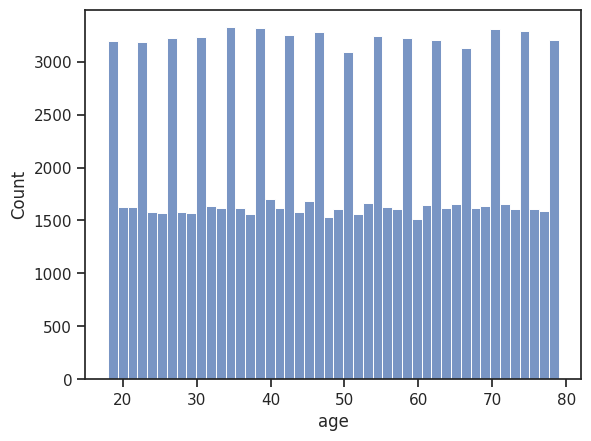

In [68]:
sns.histplot(df['age'])

<Axes: xlabel='gender', ylabel='Count'>

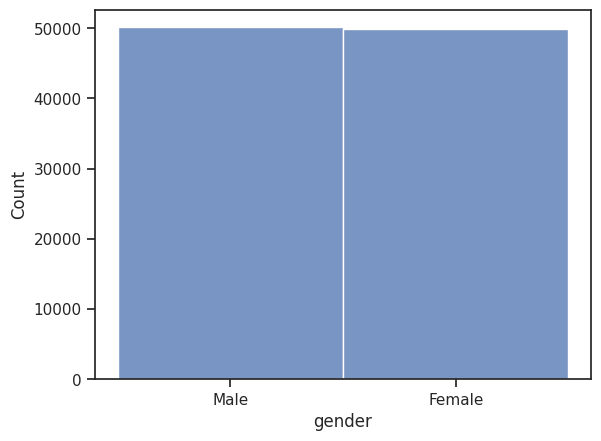

In [69]:
sns.histplot(df['gender'])

2. Cleaning Data

In [70]:
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
bmi,0
bmi_estimated,0
bmi_scaled,0
bmi_corrected,0
waist_size,0


In [71]:
# Kolom numerik
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

for col in num_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )

# Kolom kategorikal
cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        "Unknown"
    )

In [72]:
df.isnull().sum()

,0
survey_code,0
age,0
gender,0
height,0
weight,0
bmi,0
bmi_estimated,0
bmi_scaled,0
bmi_corrected,0
waist_size,0


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df = df.drop(columns=[
'survey_code',
'bmi_estimated','bmi_scaled','bmi_corrected',
'mental_health_score','mental_health_support',
'education_level','job_type','occupation',
'income','healthcare_access','insurance',
'sunlight_exposure','family_history','pet_owner',
'electrolyte_level','gene_marker_flag',
'environmental_risk_score','daily_supplement_dosage'
])

In [75]:
df.head()

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,...,smoking_level,water_intake,screen_time,stress_level,diet_type,exercise_type,device_usage,meals_per_day,caffeine_intake,target
0,56,Male,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,...,Non-smoker,1.694262,5.003963,2,Vegan,Strength,High,5,Moderate,healthy
1,69,Female,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,...,Light,0.716409,5.925455,3,Vegan,Cardio,Moderate,5,High,healthy
2,46,Male,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,...,Heavy,2.487900,4.371250,0,Vegan,Cardio,High,4,Moderate,healthy
3,32,Female,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,...,Heavy,2.643335,4.116064,10,Vegetarian,Mixed,Low,1,Unknown,healthy
4,60,Female,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,...,Heavy,1.968393,3.180087,9,Vegan,Unknown,Low,1,High,healthy


3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_5593/3608800173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='flare')


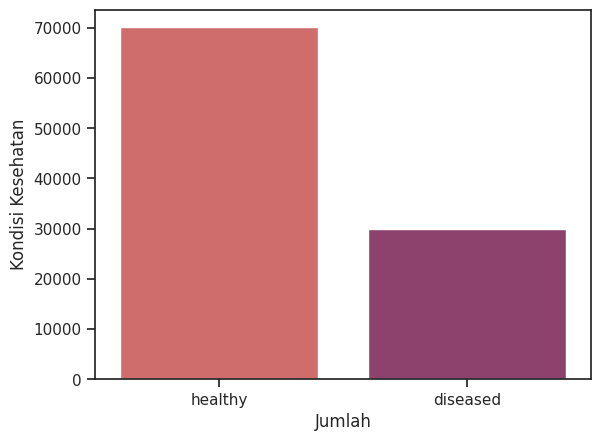

In [76]:
sns.set_theme(style='ticks')
sns.countplot(data=df, x='target', palette='flare')
plt.ylabel("Kondisi Kesehatan")
plt.xlabel("Jumlah")
plt.show()

3. Data Prep

In [77]:
df.head()

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,...,smoking_level,water_intake,screen_time,stress_level,diet_type,exercise_type,device_usage,meals_per_day,caffeine_intake,target
0,56,Male,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,...,Non-smoker,1.694262,5.003963,2,Vegan,Strength,High,5,Moderate,healthy
1,69,Female,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,...,Light,0.716409,5.925455,3,Vegan,Cardio,Moderate,5,High,healthy
2,46,Male,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,...,Heavy,2.487900,4.371250,0,Vegan,Cardio,High,4,Moderate,healthy
3,32,Female,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,...,Heavy,2.643335,4.116064,10,Vegetarian,Mixed,Low,1,Unknown,healthy
4,60,Female,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,...,Heavy,1.968393,3.180087,9,Vegan,Unknown,Low,1,High,healthy


In [78]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['gender'] = label_encoder.fit_transform(df['gender'])
df['target'] = label_encoder.fit_transform(df['target'])
df['caffeine_intake'] = label_encoder.fit_transform(df['caffeine_intake'])
df['device_usage'] = label_encoder.fit_transform(df['device_usage'])
df['alcohol_consumption'] = label_encoder.fit_transform(df['alcohol_consumption'])
df['exercise_type'] = label_encoder.fit_transform(df['exercise_type'])
df['diet_type'] = label_encoder.fit_transform(df['diet_type'])
df['sleep_quality'] = label_encoder.fit_transform(df['sleep_quality'])
df['smoking_level'] = label_encoder.fit_transform(df['smoking_level'])


In [79]:
df.head()

,age,gender,height,weight,bmi,waist_size,blood_pressure,heart_rate,cholesterol,glucose,...,smoking_level,water_intake,screen_time,stress_level,diet_type,exercise_type,device_usage,meals_per_day,caffeine_intake,target
0,56,1,173.416872,56.886640,18.915925,72.165130,118.264254,60.749825,214.580523,103.008176,...,2,1.694262,5.003963,2,2,2,0,5,1,1
1,69,0,163.207380,97.799859,36.716278,85.598889,117.917986,66.463696,115.794002,116.905134,...,1,0.716409,5.925455,3,2,0,2,5,0,1
2,46,1,177.281966,80.687562,25.673050,90.295030,123.073698,76.043212,138.134787,89.180302,...,0,2.487900,4.371250,0,2,0,0,4,1,1
3,32,0,172.101255,63.142868,21.318480,100.504211,148.173453,68.781981,203.017447,128.375798,...,0,2.643335,4.116064,10,3,1,1,1,2,1
4,60,0,163.608816,40.000000,14.943302,69.021150,150.613181,92.335358,200.412439,94.813332,...,0,1.968393,3.180087,9,2,3,1,1,0,1


In [80]:
print(df['target'].value_counts(normalize=True))

target
1    0.70097
0    0.29903
Name: proportion, dtype: float64


In [81]:
x = df.drop(columns=['target'])
y = df['target']

print("x : ", x.shape)
print("y : ", y.shape)

x :  (100000, 28)
y :  (100000,)


In [82]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [83]:
print(f"x_train : {x_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"x_test : {x_test.shape}")
print(f"y_test : {y_test.shape}")

x_train : (80000, 28)
y_train : (80000,)
x_test : (20000, 28)
y_test : (20000,)


4. Modeling

In [84]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Membuat model CatBoost
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=5,
    loss_function='Logloss',
    eval_metric='F1',
    auto_class_weights='Balanced',
    random_state=42,
    verbose=200
)

cat_model.fit(
    x_train,
    y_train,
    eval_set=(x_test, y_test),
    early_stopping_rounds=100
)

y_prob = cat_model.predict_proba(x_test)[:,1]
threshold = 0.65
y_pred = (y_prob > threshold).astype(int)



# Training model
cat_model.fit(x_train, y_train)

# Prediksi data test
y_pred = cat_model.predict(x_test)

# Menghitung akurasi
cat_acc = accuracy_score(y_test, y_pred)

# Menampilkan hasil
print(classification_report(y_test, y_pred))
print('Akurasi CatBoost = {:.2f}%'.format(cat_acc*100))

0:	learn: 0.5660186	test: 0.5589898	best: 0.5589898 (0)	total: 69.3ms	remaining: 1m 9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5589897824
bestIteration = 0

Shrink model to first 1 iterations.
0:	learn: 0.5660186	total: 135ms	remaining: 2m 15s
200:	learn: 0.5855976	total: 10.3s	remaining: 41.1s
400:	learn: 0.6100323	total: 16.1s	remaining: 24s
600:	learn: 0.6362988	total: 20.4s	remaining: 13.6s
800:	learn: 0.6563845	total: 24.8s	remaining: 6.17s
999:	learn: 0.6703459	total: 30.2s	remaining: 0us
              precision    recall  f1-score   support

           0       0.30      0.43      0.36      6023
           1       0.70      0.57      0.63     13977

    accuracy                           0.53     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.58      0.53      0.54     20000

Akurasi CatBoost = 52.70%
